# 08 - Conditional VAE

Notebook para entrenar el `ConditionalVAE` usando el mismo flujo que el AutoEncoder/VAE: dataset, validacion, scheduler, early stopping, guardado del mejor modelo y log de resultados.


In [1]:
%run init_notebook.py

import os
import time
from src.paths import *
from pathlib import Path

import torch
import torch.nn.functional as F
import torch.optim as optim
import torchaudio.transforms as T
import matplotlib.pyplot as plt
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader
from tqdm import tqdm

from config import DATA_PATH, LOGS_PATH
from src.dataset_cVAE import NSynth, nsynth_collate_fn
from src.losses import MultiDecoderLoss, MultiDecoderLoss2
from src.model_cVAE_2D import ConditionalVAE
from src.utils.logger import save_training_results

from src.ddsp_synth import DDSPSynth
from src.losses import MultiScaleSTFTLoss

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

MODEL_DIR = DATA_PATH / 'models'
CHECKPOINT_DIR = MODEL_DIR / 'checkpoints'
MODEL_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
LOGS_PATH.mkdir(parents=True, exist_ok=True)

model_path = PATHS['cVAE_2D']['model']
print('Modelo:', model_path)


Modelo: C:\Users\Articuno\Desktop\TFG-MUSICAL\data\models\cvae7_latent.pth


In [2]:
# Hiperparametros de audio / Mel
SAMPLE_RATE = 16000
N_FFT = 1024
HOP_LENGTH = 160

CVAE_N_MELS = 80
CVAE_MAX_FRAMES = 128
CVAE_INPUT_SIZE = (CVAE_N_MELS, CVAE_MAX_FRAMES)

# Hiperparametros de entrenamiento
EPOCHS = 10
BATCH_SIZE = 16
LEARNING_RATE = 1e-4
PATIENCE_ES = 15
NUM_WORKERS = 0  # en Windows/Jupyter suele ser mas estable que 2+
PIN_MEMORY = device.type == 'cuda'
RESUME = True
SAVE_EVERY = 5
GRAD_CLIP_NORM = 5.0

# Hiperparametros del modelo -> CARGADOS DESDE PATHS
# CVAE_LATENT_DIM = 128#256
# CVAE_CHANNELS = [1, 32, 64, 128, 256]
# CVAE_CONDITION_DIM = 128
# CVAE_N_HARMONICS = 64
# CVAE_DDSP_HIDDEN = 256

# Hiperparametros de la loss
BETA_MAX = 0.0001#0.01#0.1
BETA_WARMUP_EPOCHS = 30 #5
LAMBDA_MEL = 3.0 #antes 1
LAMBDA_DDSP = 0.2
LAMBDA_AUDIO = 0.0

N_INSTRUMENTOS = 11
NOMBRES_INSTRUMENTOS = {
    0: 'bass', 1: 'brass', 2: 'flute', 3: 'guitar', 4: 'keyboard',
    5: 'mallet', 6: 'organ', 7: 'reed', 8: 'string', 9: 'synth_lead', 10: 'vocal',
}

mel_transform = T.MelSpectrogram(
    sample_rate=SAMPLE_RATE,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH,
    n_mels=CVAE_N_MELS,
    power=2.0,
).to(device)


def waveforms_to_mel(waveforms):
    """Convierte waveform [B,1,T] a log-Mel [B,1,CVAE_N_MELS,CVAE_MAX_FRAMES]."""
    mel = mel_transform(waveforms)
    mel = torch.log1p(mel)

    if mel.shape[-1] > CVAE_MAX_FRAMES:
        mel = mel[..., :CVAE_MAX_FRAMES]
    elif mel.shape[-1] < CVAE_MAX_FRAMES:
        mel = F.pad(mel, (0, CVAE_MAX_FRAMES - mel.shape[-1]))

    return mel


def stack_feature(value, device):
    """Collate robusto por si algun .pt tiene distinta longitud de frames."""
    if torch.is_tensor(value):
        return value.float().to(device, non_blocking=True)

    max_len = max(v.shape[-1] for v in value)
    padded = []
    for v in value:
        v = v.float()
        if v.shape[-1] < max_len:
            v = F.pad(v, (0, max_len - v.shape[-1]))
        else:
            v = v[..., :max_len]
        padded.append(v)
    return torch.stack(padded).to(device, non_blocking=True)


def conditions_to_device(conditions, device):
    return {
        'instrument_onehot': conditions['instrument_onehot'].float().to(device, non_blocking=True),
        'pitch_norm': conditions['pitch_norm'].float().to(device, non_blocking=True),
        'velocity_norm': conditions['velocity_norm'].float().to(device, non_blocking=True),
        'brightness': conditions['brightness'].float().to(device, non_blocking=True),
        'sustain': conditions['sustain'].float().to(device, non_blocking=True),
    }


In [3]:
# Features extraidas por Extract_features.py.  
FEATURES_ROOT = DATA_PATH / 'nsynth_features'
TRAIN_FEATURES_DIR = FEATURES_ROOT / 'train'
VALID_FEATURES_DIR = FEATURES_ROOT / 'validation'


def build_nsynth_dataset(partition, features_dir):
    ds = NSynth(
        partition=partition,
        features_dir=str(features_dir),
        require_features=True,
    )
    return ds

print('Cargando training...')
train_dataset = build_nsynth_dataset('training', TRAIN_FEATURES_DIR)

valid_dataset = NSynth(
    partition='validation',
    features_dir='data/nsynth_features/validation',
    require_features=True,
)

if VALID_FEATURES_DIR.exists():
    print('Cargando validation...')
    valid_dataset = build_nsynth_dataset('validation', VALID_FEATURES_DIR)
    if len(valid_dataset) == 0:
        print('Validation no tiene .pt compatibles; se entrenara sin validacion.')
        valid_dataset = None
else:
    print(f'No existe {VALID_FEATURES_DIR}; se entrenara sin validacion.')

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=nsynth_collate_fn,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=nsynth_collate_fn,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

if valid_dataset is not None:
    valid_loader = DataLoader(
        valid_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        collate_fn=nsynth_collate_fn,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
    )

print('Train samples:', len(train_dataset))
print('Valid samples:', 0 if valid_dataset is None else len(valid_dataset))
print('Train batches:', len(train_loader))


Cargando training...
Carga completada: 289205 muestras de todos los instrumentos.
Carga completada: 12678 muestras de todos los instrumentos.
[NSynth] require_features=True: 12678 samples sin .pt omitidos (0 disponibles)
Cargando validation...
Carga completada: 12678 muestras de todos los instrumentos.
Train samples: 289205
Valid samples: 12678
Train batches: 18076


In [5]:
model = ConditionalVAE(
    input_size=CVAE_INPUT_SIZE,
    latent_dim=CVAE_LATENT_DIM,
    channels=CVAE_CHANNELS,
    condition_dim=CVAE_CONDITION_DIM,
    n_frames=CVAE_MAX_FRAMES,
    n_harmonics=CVAE_N_HARMONICS,
    ddsp_hidden=CVAE_DDSP_HIDDEN,
).to(device)

model_path = Path(model_path)

if RESUME and model_path.exists():
    state = torch.load(model_path, map_location=device)
    model.load_state_dict(state)
    print('Modelo cargado desde checkpoint existente.')
else:
    print('Entrenando desde cero.')

beta_steps = max(1, len(train_loader) * BETA_WARMUP_EPOCHS)
# loss_fn = MultiDecoderLoss2(
#     beta_max=BETA_MAX,
#     beta_steps=beta_steps,
#     lambda_mel=LAMBDA_MEL,
#     lambda_ddsp=LAMBDA_DDSP, 
# ).to(device)

synth = DDSPSynth(
    sample_rate=SAMPLE_RATE,
    block_size=HOP_LENGTH,
    win_length = N_FFT, 
    n_harmonics=CVAE_N_HARMONICS,
    use_mean_filter=True
).to(device)

# Create spectral loss
spectral_loss_fn = MultiScaleSTFTLoss(
    n_fft_list=[512, 1024, 2048],
    hop_length_list=[50, 120, 240],
    win_length_list=[512, 1024, 2048],
).to(device)


loss_fn = MultiDecoderLoss2(
    beta_max=BETA_MAX,
    beta_steps=10000,
    lambda_mel=1.0,
    lambda_ddsp=1.0,
    free_bits=0.5,
    free_bits_mode="per_channel",
).to(device)

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parametros entrenables: {n_params:,}')
print(f'Beta warmup steps: {beta_steps}')


Modelo cargado desde checkpoint existente.


c:\Users\Articuno\Desktop\TFG-MUSICAL\env-musical-serious-business\Lib\site-packages\tqdm\auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html

[transformers] Disabling PyTorch because PyTorch >= 2.5 is required but found 2.1.0+cu121
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


Parametros entrenables: 1,654,979
Beta warmup steps: 542280


In [6]:
print("1. antes de crear iterador", flush=True)

it = iter(train_loader)

print("2. iterador creado", flush=True)

batch = next(it)

print("3. batch obtenido", flush=True)

mels, keys, metadatas, features, conditions = batch

print("4. batch desempaquetado", flush=True)

mels = mels.to(device, non_blocking=True)

print("5. mels enviados a GPU", flush=True)

mel_orig = mels

print("6. antes de conditions_to_device", flush=True)

cond = conditions_to_device(conditions, device)

print("7. conditions enviadas a GPU", flush=True)

print("8. antes del model()", flush=True)

with torch.no_grad():
    mel_hat, ddsp_params, kld, mu, logvar = model(
        mel_orig,
        cond['instrument_onehot'],
        cond['pitch_norm'],
        cond['velocity_norm'],
        cond['brightness'],
        cond['sustain'],
    )

print("9. model() terminado", flush=True)

print('mel_orig:', tuple(mel_orig.shape), flush=True)
print('mel_hat :', tuple(mel_hat.shape), flush=True)
print('f0      :', tuple(ddsp_params['f0_scale'].shape), flush=True)
print('loudness:', tuple(ddsp_params['loudness_scale'].shape), flush=True)
print('harm    :', tuple(ddsp_params['harmonics'].shape), flush=True)
print('kld     :', tuple(kld.shape), flush=True)

1. antes de crear iterador
2. iterador creado


c:\Users\Articuno\Desktop\TFG-MUSICAL\env-musical-serious-business\Lib\site-packages\torch\_utils.py:831: UserWarning:

TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()



3. batch obtenido
4. batch desempaquetado
5. mels enviados a GPU
6. antes de conditions_to_device
7. conditions enviadas a GPU
8. antes del model()
9. model() terminado
mel_orig: (16, 1, 80, 128)
mel_hat : (16, 1, 80, 128)
f0      : (16, 128)
loudness: (16, 128)
harm    : (16, 128, 64)
kld     : (16,)


In [7]:
f0 = ddsp_params["f0_scale"][:2]
loudness = ddsp_params["loudness_scale"][:2]
harmonics = ddsp_params["harmonics"][:2]

audio = synth(f0, loudness, harmonics)

print("audio:", audio.shape)
print("dtype:", audio.dtype)
print("NaN:", torch.isnan(audio).any())
print("Inf:", torch.isinf(audio).any())

audio: torch.Size([2, 20480])
dtype: torch.float32
NaN: tensor(False, device='cuda:0')
Inf: tensor(False, device='cuda:0')


In [ ]:
#el checkpoint, early stopping y scheduler usan la misma métrica, metric = mel reconstruction loss
def run_epoch(loader, train=True):
    model.train(train)
    totals = {
        'total': 0.0,
        'mel': 0.0,
        'ddsp': 0.0,
        'f0': 0.0,
        'loudness': 0.0,
        'kld': 0.0,
        'beta': 0.0,
    }
    n_seen = 0

    desc = 'train' if train else 'valid'
    iterator = tqdm(loader, desc=desc, leave=False)
    context = torch.enable_grad() if train else torch.no_grad()

    with context:
        for batch in iterator:
            mels,  keys, metadatas, features, conditions = batch
           # waveforms = waveforms.to(device, non_blocking=True)
           # mel_orig = waveforms_to_mel(waveforms)
            mels = mels.to(device, non_blocking=True)
            mel_orig = mels 
            cond = conditions_to_device(conditions, device)
            features_real = {
                'f0': stack_feature(features['f0'], device),
                'loudness_db': stack_feature(features['loudness_db'], device),
            }

            if train:
                optimizer.zero_grad(set_to_none=True)
            
            mel_hat, ddsp_params, kld, mu, logvar = model(
                mel_orig,
                cond['instrument_onehot'],
                cond['pitch_norm'],
                cond['velocity_norm'],
                cond['brightness'],
                cond['sustain'],
            )
            
            # --- DDSP synthesis ---
            if LAMBDA_AUDIO > 0:
                audio_hat = synth(
                    ddsp_params['f0_scale'],
                    ddsp_params['loudness_scale'],
                    ddsp_params['harmonics'],
                )
                loss_audio = spectral_loss_fn(audio_hat, mel_orig)  # mel_orig as proxy for audio
            else:
                loss_audio = 0.0

            loss, loss_dict = loss_fn(mel_orig, mel_hat, ddsp_params, features_real, kld, mu, logvar)

            # Add audio loss to total   
            if LAMBDA_AUDIO > 0:
                loss = loss + (LAMBDA_AUDIO * loss_audio)
                loss_dict['audio'] = loss_audio.item() if isinstance(loss_audio, torch.Tensor) else loss_audio
            # print(
            #     f"LOSS={loss.item():.8f} | "
            #     f"MEL={loss_dict['mel']:.8f} | "
            #     f"DDSP={loss_dict['ddsp']:.8f} | "
            #     f"F0={loss_dict['f0']:.8f} | "
            #     f"LOUD={loss_dict['loudness']:.8f} | "
            #     f"KL={loss_dict['kld']:.8f} | "
            #     f"BETA={loss_dict['beta']:.8f} | "
            #     f"BETA*KL={(loss_dict['beta'] * loss_dict['kld']):.8f}",
            #     flush=True
            # )
            
            # print(
            #     "current_step =", loss_fn.current_step,
            #     "beta =", loss_fn.beta,
            #     "beta_max =", loss_fn.beta_max,
            #     "beta_steps =", loss_fn.beta_steps,
            #     "lambda_ddsp =", loss_fn.lambda_ddsp,
            #     "free_bits =", loss_fn.free_bits,
            #     "free_bits_mode =", loss_fn.free_bits_mode,
            #     flush=True
            # )

            if train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
                optimizer.step()
                loss_fn.step_beta()

            batch_size = mels.shape[0] #waveforms.shape[0]
            n_seen += batch_size
            totals['total'] += loss.item() * batch_size
            for key in ['mel', 'ddsp', 'f0', 'loudness', 'kld', 'beta']:
                    totals[key] += float(loss_dict[key]) * batch_size

            iterator.set_postfix(
                loss=f'{loss.item():.4f}',
                mel=f"{loss_dict['mel']:.4f}",
                ddsp=f"{loss_dict['ddsp']:.4f}",
                beta=f"{loss_dict['beta']:.4f}",
            )

    return {key: value / max(1, n_seen) for key, value in totals.items()}


history = {
    'train_total': [], 'train_mel': [], 'train_ddsp': [], 'train_f0': [],
    'train_loudness': [], 'train_kld': [], 'train_beta': [],
    'valid_total': [], 'valid_mel': [], 'valid_ddsp': [], 'valid_f0': [],
    'valid_loudness': [], 'valid_kld': [], 'valid_beta': [],
}

best_metric = float('inf')
epochs_no_improve = 0
total_epoch_time = 0.0

print('Starting training on', device)

for epoch in range(1, EPOCHS + 1):
    start = time.time()

    train_stats = run_epoch(train_loader, train=True)
    for key, value in train_stats.items():
        history[f'train_{key}'].append(value)

    if valid_loader is not None:
        valid_stats = run_epoch(valid_loader, train=False)
        for key, value in valid_stats.items():
            history[f'valid_{key}'].append(value)

       # metric = valid_stats['total']   # usamos validation loss
        metric = valid_stats['mel']

    else:
        valid_stats = None
        metric = train_stats['mel']   # fallback si no hay validation
        """
        metric = (
            train_stats['mel']
            + 0.5 * train_stats['ddsp']
            + train_stats['beta'] * train_stats['kld']
        )
        """

    scheduler.step(metric)

    epoch_time = time.time() - start
    total_epoch_time += epoch_time

    if valid_stats is None:
        print(
            f"Epoch {epoch:03d} | "
            f"train={train_stats['total']:.4f} "
            f"mel={train_stats['mel']:.4f} ddsp={train_stats['ddsp']:.4f} "
            f"kld={train_stats['kld']:.4f¡} beta={train_stats['beta']:.4f} "
            f"time={epoch_time:.1f}s"
        )
    else:
       print(
            f"Epoch {epoch:03d} | "
            f"train={train_stats['total']:.4f} valid={valid_stats['total']:.4f} "
            f"metric={metric:.4f} "
            f"mel={valid_stats['mel']:.4f} ddsp={valid_stats['ddsp']:.4f} "
            f"kld={valid_stats['kld']:.4f} beta={valid_stats['beta']:.4f} "
            f"time={epoch_time:.1f}s"
        )

    if metric < best_metric:
        best_metric = metric
        epochs_no_improve = 0
        torch.save(model.state_dict(), model_path)
        print(f'  Mejor modelo guardado en: {model_path}')
    else:
        epochs_no_improve += 1

    if epoch % SAVE_EVERY == 0:
        epoch_ckpt = CHECKPOINT_DIR / f'cvae_epoch_{epoch:03d}.pth'
        torch.save(model.state_dict(), epoch_ckpt)
        print(f'  Checkpoint guardado en: {epoch_ckpt}')

    if epochs_no_improve >= PATIENCE_ES:
        print(f'Early stopping en epoch {epoch}.')
        break

print('Training complete.')


Starting training on cuda


Epoch 001 | train=0.1733 valid=0.2680 metric=0.1111 mel=0.1111 ddsp=0.1033 kld=535.9897 beta=0.0001 time=3346.5s
  Mejor modelo guardado en: C:\Users\Articuno\Desktop\TFG-MUSICAL\data\models\cvae7_latent.pth


Epoch 002 | train=0.1887 valid=0.2608 metric=0.1111 mel=0.1111 ddsp=0.0969 kld=527.9470 beta=0.0001 time=329.8s


Epoch 003 | train=0.1873 valid=0.2613 metric=0.1084 mel=0.1084 ddsp=0.0987 kld=542.1464 beta=0.0001 time=325.9s
  Mejor modelo guardado en: C:\Users\Articuno\Desktop\TFG-MUSICAL\data\models\cvae7_latent.pth


Epoch 004 | train=0.1863 valid=0.2603 metric=0.1089 mel=0.1089 ddsp=0.0978 kld=535.7276 beta=0.0001 time=325.6s


...

Epoch 006 | train=0.1845 valid=0.2563 metric=0.1077 mel=0.1077 ddsp=0.0944 kld=541.9183 beta=0.0001 time=327.0s
  Mejor modelo guardado en: C:\Users\Articuno\Desktop\TFG-MUSICAL\data\models\cvae7_latent.pth


Epoch 007 | train=0.1837 valid=0.2602 metric=0.1075 mel=0.1075 ddsp=0.0985 kld=542.0068 beta=0.0001 time=326.8s
  Mejor modelo guardado en: C:\Users\Articuno\Desktop\TFG-MUSICAL\data\models\cvae7_latent.pth


Epoch 008 | train=0.1829 valid=0.2610 metric=0.1069 mel=0.1069 ddsp=0.0995 kld=546.0091 beta=0.0001 time=328.1s
  Mejor modelo guardado en: C:\Users\Articuno\Desktop\TFG-MUSICAL\data\models\cvae7_latent.pth


Epoch 009 | train=0.1821 valid=0.2634 metric=0.1055 mel=0.1055 ddsp=0.1035 kld=543.6193 beta=0.0001 time=326.7s
  Mejor modelo guardado en: C:\Users\Articuno\Desktop\TFG-MUSICAL\data\models\cvae7_latent.pth


Epoch 010 | train=0.1814 valid=0.2641 metric=0.1053 mel=0.1053 ddsp=0.1042 kld=545.6502 beta=0.0001 time=327.6s
  Mejor modelo guardado en: C:\Users\Articuno\Desktop\TFG-MUSICAL\data\models\cvae7_latent.pth
  Checkpoint guardado en: C:\Users\Articuno\Desktop\TFG-MUSICAL\data\models\checkpoints\cvae_epoch_010.pth
Training complete.


In [ ]:
results = {
    'train_total': history['train_total'],
    'train_mel': history['train_mel'],
    'train_ddsp': history['train_ddsp'],
    'train_f0': history['train_f0'],
    'train_loudness': history['train_loudness'],
    'train_kld': history['train_kld'],
    'train_beta': history['train_beta'],
    'valid_total': history['valid_total'],
    'valid_mel': history['valid_mel'],
    'valid_ddsp': history['valid_ddsp'],
    'valid_f0': history['valid_f0'],
    'valid_loudness': history['valid_loudness'],
    'valid_kld': history['valid_kld'],
    'valid_beta': history['valid_beta'],
    'num_epochs': len(history['train_total']),
    'avg_epoch_time': total_epoch_time / max(1, len(history['train_total'])),
    'best_metric': best_metric,
    'model_path': str(model_path),
    'learning_rate': LEARNING_RATE,
    'batch_size': BATCH_SIZE,
    'sample_rate': SAMPLE_RATE,
    'n_fft': N_FFT,
    'hop_length': HOP_LENGTH,
    'n_mels': CVAE_N_MELS,
    'max_frames': CVAE_MAX_FRAMES,
    'input_size': CVAE_INPUT_SIZE,
    'latent_dim': CVAE_LATENT_DIM,
    'channels': CVAE_CHANNELS,
    'condition_dim': CVAE_CONDITION_DIM,
    'n_harmonics': CVAE_N_HARMONICS,
    'beta_max': BETA_MAX,
    'beta_warmup_epochs': BETA_WARMUP_EPOCHS,
    'lambda_mel': LAMBDA_MEL,
    'lambda_ddsp': LAMBDA_DDSP,
}

save_training_results(results, 'cvae.json')
print('Resultados guardados en:', LOGS_PATH / 'cvae.json')
print('Mejor modelo:', model_path)


Resultados guardados en: C:\Users\Articuno\Desktop\TFG-MUSICAL\logs\cvae.json
Mejor modelo: C:\Users\Articuno\Desktop\TFG-MUSICAL\data\models\cvae7_latent.pth


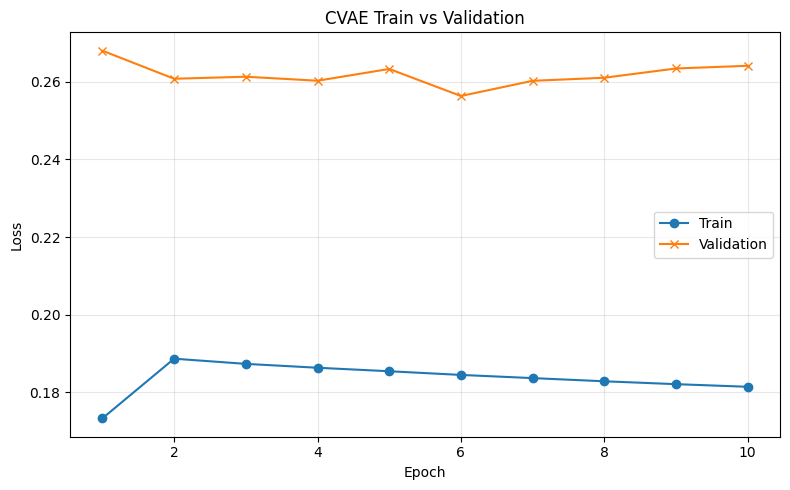

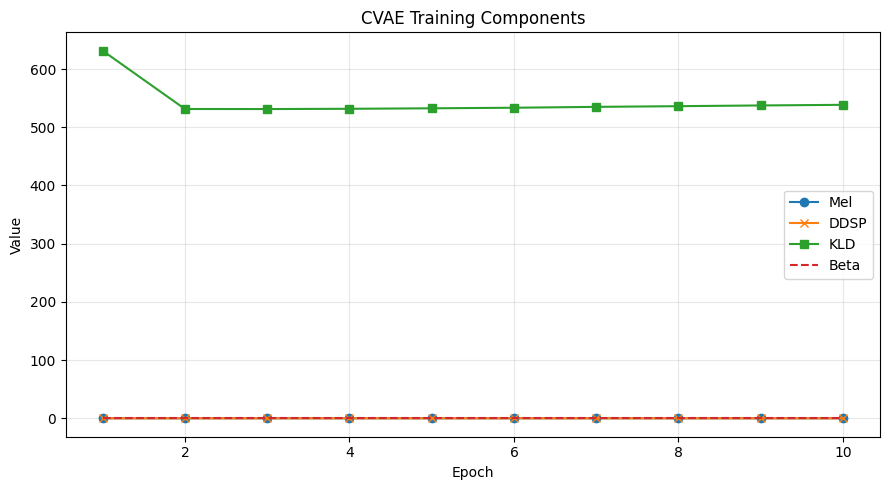

In [16]:
epochs = range(1, len(history['train_total']) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history['train_total'], label='Train', marker='o')
if history['valid_total']:
    plt.plot(epochs, history['valid_total'], label='Validation', marker='x')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CVAE Train vs Validation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(epochs, history['train_mel'], label='Mel', marker='o')
plt.plot(epochs, history['train_ddsp'], label='DDSP', marker='x')
plt.plot(epochs, history['train_kld'], label='KLD', marker='s')
plt.plot(epochs, history['train_beta'], label='Beta', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('CVAE Training Components')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [9]:
from IPython.display import Audio, display
import torchaudio.transforms as T
import torch

# 1. Aseguramos el dispositivo y cargamos el mejor modelo de la validación
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Cargando el cerebro de la IA...")

# IMPORTANTE: asegurarse d que los canales y todo coinciden con cómo entrenamos
# Si cambiaste algo, ponlo igual aquí.
#model.load_state_dict(torch.load("checkpoints/cvae_best_val.pt"))
state = torch.load(model_path, map_location=device)
model.load_state_dict(state)
model.eval() # Apagamos el modo entrenamiento

# PANEL DE CONTROL 
# Familias NSynth: 0=bass, 1=brass, 2=flute, 3=guitar, 4=keyboard...
ELEGIR_INSTRUMENTO = 3 # 3 = Guitarra
ELEGIR_PITCH = 60      # 60 = Do central
ELEGIR_VELOCITY = 100  # Fuerza (0-127)
ELEGIR_BRILLO = 0.8    # 0.0 a 1.0 (0.8 = bastante brillante)
ELEGIR_SUSTAIN = 0.6   # 0.0 a 1.0 (0.2 = decae rápido, típico de guitarra)

inst_oh = torch.zeros(1, 11).to(device)
inst_oh[0, ELEGIR_INSTRUMENTO] = 1.0

pitch_n = torch.tensor([[ELEGIR_PITCH / 127.0]]).to(device)
vel_n = torch.tensor([[ELEGIR_VELOCITY / 127.0]]).to(device)
bright = torch.tensor([[ELEGIR_BRILLO]]).to(device)
sustain = torch.tensor([[ELEGIR_SUSTAIN]]).to(device)

# GENERACIÓN DESDE CERO
print(f"Generando Familia {ELEGIR_INSTRUMENTO} en MIDI {ELEGIR_PITCH}...")

with torch.no_grad():
    # Usamos tu método 'sample' directamente
    mel_generado, ddsp_generado = model.sample(
        inst_oh, pitch_n, vel_n, bright, sustain, n_samples=1
    )

# ESCUCHAR con Griffin-Lim)

print("Traduciendo el espectrograma a audio...")
print(mel_generado.shape)

# Parámetros (los mismos del entrenamiento)
SAMPLE_RATE = 16000
N_FFT = 1024
HOP_LENGTH = 160
CVAE_N_MELS = 80
N_STFT = N_FFT // 2 + 1  # Esto da exactamente 513

# 1. El estirador: Pasa de 80 bandas Mel a 513 bandas Lineales
inverse_mel = T.InverseMelScale(
    n_stft=N_STFT,
    n_mels=CVAE_N_MELS,
    sample_rate=SAMPLE_RATE
).to(device)

# 2. El vocoder: Pasa de 513 bandas Lineales a Onda de Audio pura
griffin_lim = T.GriffinLim(
    n_fft=N_FFT, 
    hop_length=HOP_LENGTH, 
    power=2.0
).to(device)

with torch.no_grad():
    # mel_generado tiene shape (1, 1, 80, 128). Nos quedamos con la imagen [0]
    mel_img = mel_generado[0]
    
    # Aplicamos el puente
    mel_lineal = torch.expm1(mel_img)
    mel_lineal = mel_lineal.clamp_min(0.0)

    espectrograma_lineal = inverse_mel(mel_lineal)
    audio_waveform = griffin_lim(espectrograma_lineal)

print("¡Audio listo! Dale al play:")
display(Audio(audio_waveform.cpu().squeeze().numpy(), rate=SAMPLE_RATE))

Cargando el cerebro de la IA...
Generando Familia 3 en MIDI 60...
Traduciendo el espectrograma a audio...
torch.Size([1, 1, 80, 128])
¡Audio listo! Dale al play:


In [10]:
import random
from IPython.display import Audio, display
import torchaudio.transforms as T
import torch

# Carga del modelo (una sola vez) 
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Cargando el cerebro de la IA...")
state = torch.load(model_path, map_location=device)
model.load_state_dict(state)
model.eval()

# Vocoder (Mel -> audio), se crea una sola vez 
SAMPLE_RATE = 16000
N_FFT = 1024
HOP_LENGTH = 160
CVAE_N_MELS = 80
N_STFT = N_FFT // 2 + 1  # 513

inverse_mel = T.InverseMelScale(
    n_stft=N_STFT, n_mels=CVAE_N_MELS, sample_rate=SAMPLE_RATE
).to(device)

griffin_lim = T.GriffinLim(
    n_fft=N_FFT, hop_length=HOP_LENGTH, power=2.0
).to(device)

N_INSTRUMENTOS = 11
NOMBRES_INSTRUMENTOS = {
    0: 'bass', 1: 'brass', 2: 'flute', 3: 'guitar', 4: 'keyboard',
    5: 'mallet', 6: 'organ', 7: 'reed', 8: 'string', 9: 'synth_lead', 10: 'vocal',
}


def _resolver_param(valor, n, low, high, es_entero=False):
    """
    Normaliza un parametro a una lista de n valores:
      - None            -> n valores aleatorios en [low, high]
      - escalar          -> se repite n veces (mismo valor pa todas las muestras)
      - lista/tupla       -> debe tener longitud n, un valor por muestra
    """
    if valor is None:
        if es_entero:
            return [random.randint(low, high) for _ in range(n)]
        return [random.uniform(low, high) for _ in range(n)]

    if isinstance(valor, (list, tuple)):
        if len(valor) != n:
            raise ValueError(f'Se esperaban {n} valores y llegaron {len(valor)}.')
        return list(valor)

    return [valor] * n  # escalar -> mismo valor para las n muestras


def _mel_a_audio(mel_img):
    """mel_img: (1, H, W) log-mel de UNA muestra -> waveform numpy."""
    with torch.no_grad():
        mel_lineal = torch.expm1(mel_img).clamp_min(0.0)
        espectrograma_lineal = inverse_mel(mel_lineal)
        audio_waveform = griffin_lim(espectrograma_lineal)
    return audio_waveform.cpu().squeeze().numpy()


@torch.no_grad()
def generar_sonidos(n=1, instrumento=None, pitch=None, velocity=None,
                     brillo=None, sustain=None):
    """
    Genera n sonidos con el modelo.

    Cada parametro admite:
      - None                -> aleatorio, distinto por muestra
      - un valor             -> igual para las n muestras
      - lista de n valores    -> uno por muestra

    Rangos: instrumento 0-10, pitch 0-127 (MIDI), velocity 0-127,
    brillo/sustain 0.0-1.0.

    Retorna una lista de dicts: {'audio', 'config', 'mel'}
    """
    instrumentos = _resolver_param(instrumento, n, 0, N_INSTRUMENTOS - 1, es_entero=True)
    pitches      = _resolver_param(pitch, n, 24, 96, es_entero=True)     # rango tipico NSynth
    velocities   = _resolver_param(velocity, n, 25, 127, es_entero=True)
    brillos      = _resolver_param(brillo, n, 0.0, 1.0)
    sustains     = _resolver_param(sustain, n, 0.0, 1.0)

    inst_oh = torch.zeros(n, N_INSTRUMENTOS, device=device)
    for i, ins in enumerate(instrumentos):
        inst_oh[i, ins] = 1.0

    pitch_n   = torch.tensor([[p / 127.0] for p in pitches], device=device)
    vel_n     = torch.tensor([[v / 127.0] for v in velocities], device=device)
    bright_t  = torch.tensor([[b] for b in brillos], device=device)
    sustain_t = torch.tensor([[s] for s in sustains], device=device)

    mel_generado, ddsp_generado = model.sample(
        inst_oh, pitch_n, vel_n, bright_t, sustain_t, n_samples=n
    )

    resultados = []
    for i in range(n):
        audio = _mel_a_audio(mel_generado[i])
        config = {
            'instrumento': instrumentos[i],
            'instrumento_nombre': NOMBRES_INSTRUMENTOS.get(instrumentos[i], '?'),
            'pitch': pitches[i],
            'velocity': velocities[i],
            'brillo': round(brillos[i], 3),
            'sustain': round(sustains[i], 3),
        }
        resultados.append({'audio': audio, 'config': config, 'mel': mel_generado[i].cpu()})

    return resultados


def mostrar_sonidos(resultados):
    for i, r in enumerate(resultados):
        c = r['config']
        print(f"[{i}] {c['instrumento_nombre']} (fam {c['instrumento']}) | "
              f"MIDI {c['pitch']} | vel {c['velocity']} | "
              f"brillo {c['brillo']} | sustain {c['sustain']}")
        display(Audio(r['audio'], rate=SAMPLE_RATE))

Cargando el cerebro de la IA...


In [11]:
# 5 sonidos totalmente aleatorios
resultados = generar_sonidos(n=5)
mostrar_sonidos(resultados)

# 3 guitarras (mismo instrumento), pitch distinto en cada una, resto aleatorio
resultados = generar_sonidos(n=3, instrumento=3, pitch=[48, 60, 72])
mostrar_sonidos(resultados)

# Lo mismo que tu celda original, exacto
resultados = generar_sonidos(n=1, instrumento=3, pitch=60, velocity=100, brillo=0.8, sustain=0.6)
mostrar_sonidos(resultados)

[0] brass (fam 1) | MIDI 94 | vel 52 | brillo 0.963 | sustain 0.415


[1] synth_lead (fam 9) | MIDI 59 | vel 99 | brillo 0.099 | sustain 0.592


[2] organ (fam 6) | MIDI 35 | vel 29 | brillo 0.333 | sustain 0.751


[3] keyboard (fam 4) | MIDI 51 | vel 107 | brillo 0.464 | sustain 0.434


[4] synth_lead (fam 9) | MIDI 67 | vel 42 | brillo 0.583 | sustain 0.494


[0] guitar (fam 3) | MIDI 48 | vel 119 | brillo 0.437 | sustain 0.86


[1] guitar (fam 3) | MIDI 60 | vel 109 | brillo 0.863 | sustain 0.917


[2] guitar (fam 3) | MIDI 72 | vel 53 | brillo 0.485 | sustain 0.277


[0] guitar (fam 3) | MIDI 60 | vel 100 | brillo 0.8 | sustain 0.6


In [12]:
import torch
import torchaudio.transforms as T
from IPython.display import Audio, display

# ============================================================
# SANITY CHECK:
# Mel REAL -> InverseMelScale -> GriffinLim -> Audio
# ============================================================

# Cogemos un batch real de validación
batch =next(iter(valid_loader))

mels, keys, metadatas, features, conditions = batch

# Primera muestra del batch
mel_real = mels[0].to(device)

print("Shape del mel original:", mel_real.shape)

# Si tu dataset devuelve (1, CVAE_N_MELS, N_FRAMES),
# quitamos el canal para trabajar con (CVAE_N_MELS, N_FRAMES)
if mel_real.dim() == 3:
    mel_real = mel_real.squeeze(0)

# ------------------------------------------------------------
# 1. Deshacer log1p
# ------------------------------------------------------------

# Tu pipeline de entrenamiento usa:
# mel = torch.log1p(mel_transform(waveform))
#
# Por tanto:
# mel_lineal = exp(mel) - 1

mel_linear = torch.expm1(mel_real)

# Evitamos valores negativos por posibles errores numéricos
mel_linear = torch.clamp(mel_linear, min=0.0)

# ------------------------------------------------------------
# 2. Mel -> espectrograma lineal
# ------------------------------------------------------------

inverse_mel = T.InverseMelScale(
    n_stft=N_FFT // 2 + 1,
    n_mels=CVAE_N_MELS,
    sample_rate=SAMPLE_RATE
).to(device)

linear_spec = inverse_mel(mel_linear)

# ------------------------------------------------------------
# 3. Espectrograma -> audio con Griffin-Lim
# ------------------------------------------------------------

griffin_lim = T.GriffinLim(
    n_fft=N_FFT,
    hop_length=HOP_LENGTH,
    power=2.0,
    n_iter=64
).to(device)

waveform = griffin_lim(linear_spec)

# ------------------------------------------------------------
# 4. Normalización para escuchar
# ------------------------------------------------------------

waveform = waveform.cpu()

waveform = waveform / (
    waveform.abs().max() + 1e-8
)

audio = waveform.numpy()

print("Duración aproximada:", len(audio) / SAMPLE_RATE, "segundos")

display(Audio(audio, rate=SAMPLE_RATE))

Shape del mel original: torch.Size([1, 80, 128])
Duración aproximada: 1.27 segundos


In [17]:
@torch.no_grad()
def reconstruir_desde_loader(loader, n=4, batch=None,
                              incluir_original=True, determinista=True,
                              forzar_instrumento=None, forzar_pitch=None,
                              forzar_velocity=None, forzar_brillo=None,
                              forzar_sustain=None):
    """
    Coge un batch real (train o valid) y lo pasa por el cVAE completo
    (encoder + decoder). Por defecto usa las condiciones REALES del dataset,
    pero cualquiera de ellas se puede forzar a un valor fijo via los args
    forzar_*, sustituyendo lo que traiga el sample. Sirve para evaluar que
    tan bien reconstruye el modelo audio que ya conoce (o como suena ese
    mismo audio bajo otras condiciones), a diferencia de generar_sonidos()
    que parte de ruido puro via model.sample().

    Args:
        loader           : DataLoader (train_loader o valid_loader)
        n                : cuantas muestras reconstruir del batch
        batch             : reusa un batch ya sacado, si no None
                            (evita gastar otro next(iter(loader)))
        incluir_original  : si True, tambien vocodea el mel real para comparar
        determinista      : si True, usa z=mu (sin ruido de reparametrizacion)
                            -> reconstruccion repetible, recomendado para evaluar
                            calidad. Si False, usa el forward() normal con
                            muestreo estocastico (mismo audio da resultados
                            ligeramente distintos cada vez).
        forzar_instrumento: None, int, o lista/tensor de ints (largo n).
                            Si se da, reemplaza el instrument_onehot real.
        forzar_pitch      : None, float, o lista/tensor de floats en [0,1]
                            (largo n). Reemplaza pitch_norm real.
        forzar_velocity   : idem para velocity_norm.
        forzar_brillo     : idem para brightness.
        forzar_sustain    : idem para sustain.

    Ejemplo: mismas n muestras del loader, pero todas con instrumento=2
    y brillo alto, conservando su pitch/velocity/sustain reales:
        reconstruir_desde_loader(valid_loader, n=4,
                                  forzar_instrumento=2, forzar_brillo=0.9)

    Retorna lista de dicts: {'audio_hat', 'audio_orig'?, 'config', 'mel_hat', 'mel_orig', 'key'}
    """
    if batch is None:
        batch = next(iter(loader))

    mels, keys, metadatas, features, conditions = batch
    n = min(n, mels.shape[0])

    mel_orig = mels[:n].to(device)
    cond = conditions_to_device(conditions, device)
    cond = {k: v[:n] for k, v in cond.items()}  # recorta batch a n muestras

    # --- forzar condiciones: si se especifican, sustituyen a las reales ---
    def _expandir(valor, ref):
        """Convierte escalar/lista/tensor en un tensor con la forma de `ref` (n muestras)."""
        if torch.is_tensor(valor):
            t = valor.to(device).float()
        else:
            if not isinstance(valor, (list, tuple)):
                valor = [valor] * n
            t = torch.tensor(valor, dtype=torch.float32, device=device)
        if t.numel() == 1:
            t = t.expand(n).clone()
        assert t.numel() == n, f"se esperaban {n} valores, llegaron {t.numel()}"
        return t.view(ref.shape)

    if forzar_instrumento is not None:
        n_instrumentos = cond['instrument_onehot'].shape[-1]
        idx = _expandir(forzar_instrumento, cond['instrument_onehot'][:, 0]).long()
        onehot = torch.zeros(n, n_instrumentos, device=device)
        onehot.scatter_(1, idx.unsqueeze(1), 1.0)
        cond['instrument_onehot'] = onehot

    if forzar_pitch is not None:
        cond['pitch_norm'] = _expandir(forzar_pitch, cond['pitch_norm'])

    if forzar_velocity is not None:
        cond['velocity_norm'] = _expandir(forzar_velocity, cond['velocity_norm'])

    if forzar_brillo is not None:
        cond['brightness'] = _expandir(forzar_brillo, cond['brightness'])

    if forzar_sustain is not None:
        cond['sustain'] = _expandir(forzar_sustain, cond['sustain'])

    # Monkeypatch temporal: z = mu en vez de mu + eps*std (reconstruccion sin ruido)
    reparam_original = model.reparameterize
    if determinista:
        model.reparameterize = lambda mu, logvar: mu
    try:
        mel_hat, ddsp_params, kld, mu, logvar = model(
            mel_orig,
            cond['instrument_onehot'],
            cond['pitch_norm'],
            cond['velocity_norm'],
            cond['brightness'],
            cond['sustain'],
        )
    finally:
        model.reparameterize = reparam_original  # restaurar siempre, incluso si falla

    resultados = []
    for i in range(n):
        inst_idx = int(cond['instrument_onehot'][i].argmax().item())
        entry = {
            'audio_hat': _mel_a_audio(mel_hat[i]),
            'mel_hat':   mel_hat[i].cpu(),
            'mel_orig':  mel_orig[i].cpu(),
            'key':       keys[i] if keys is not None else None,
            'config': {
                'instrumento':        inst_idx,
                'instrumento_nombre': NOMBRES_INSTRUMENTOS.get(inst_idx, '?'),
                'pitch_norm':         round(float(cond['pitch_norm'][i].item()), 3),
                'velocity_norm':      round(float(cond['velocity_norm'][i].item()), 3),
                'brillo':             round(float(cond['brightness'][i].item()), 3),
                'sustain':            round(float(cond['sustain'][i].item()), 3),
            },
        }
        if incluir_original:
            entry['audio_orig'] = _mel_a_audio(mel_orig[i])
        resultados.append(entry)

    return resultados


def mostrar_reconstrucciones(resultados, incluir_original=True):
    for i, r in enumerate(resultados):
        c = r['config']
        etiqueta_key = f" | key={r['key']}" if r.get('key') is not None else ""
        print(f"[{i}] {c['instrumento_nombre']} (fam {c['instrumento']}) | "
              f"pitch_norm {c['pitch_norm']} | vel_norm {c['velocity_norm']} | "
              f"brillo {c['brillo']} | sustain {c['sustain']}{etiqueta_key}")
        if incluir_original and 'audio_orig' in r:
            print("  Original:")
            display(Audio(r['audio_orig'], rate=SAMPLE_RATE))
        print("  Reconstruido:")
        display(Audio(r['audio_hat'], rate=SAMPLE_RATE))

In [ ]:
# 4 muestras del set de validación, reconstrucción determinista (z=mu), con comparación
# resultados = reconstruir_desde_loader(valid_loader, n=4)
# mostrar_reconstrucciones(resultados)

# Con muestreo estocástico (para ver variabilidad del VAE en la misma entrada)
# resultados = reconstruir_desde_loader(valid_loader, n=4, determinista=False)
# mostrar_reconstrucciones(resultados)

# Reusando el mismo batch para no gastar otro next(iter(...))
batch = next(iter(valid_loader))
res_a = reconstruir_desde_loader(valid_loader, n=1, batch=batch, determinista=False, forzar_instrumento=1)
res_b = reconstruir_desde_loader(valid_loader, n=1, batch=batch, determinista=False, forzar_instrumento=2)
res_c = reconstruir_desde_loader(valid_loader, n=1, batch=batch, determinista=False, forzar_instrumento=3)
res_d = reconstruir_desde_loader(valid_loader, n=1, batch=batch, determinista=False, forzar_instrumento=4)
mostrar_reconstrucciones(res_a, incluir_original=False)
mostrar_reconstrucciones(res_b, incluir_original=False)
mostrar_reconstrucciones(res_c, incluir_original=False)
mostrar_reconstrucciones(res_d, incluir_original=False)

[0] brass (fam 1) | pitch_norm 0.472 | vel_norm 0.197 | brillo 0.0 | sustain 0.0 | key=keyboard_acoustic_004-060-025
  Reconstruido:


[0] flute (fam 2) | pitch_norm 0.472 | vel_norm 0.197 | brillo 0.0 | sustain 0.0 | key=keyboard_acoustic_004-060-025
  Reconstruido:


[0] guitar (fam 3) | pitch_norm 0.472 | vel_norm 0.197 | brillo 0.0 | sustain 0.0 | key=keyboard_acoustic_004-060-025
  Reconstruido:


[0] keyboard (fam 4) | pitch_norm 0.472 | vel_norm 0.197 | brillo 0.0 | sustain 0.0 | key=keyboard_acoustic_004-060-025
  Reconstruido:


### PCA y t-SNE

[PCA] varianza explicada PC1=0.085 PC2=0.067 (total=0.152)
Guardado en pca_latents_grid.png


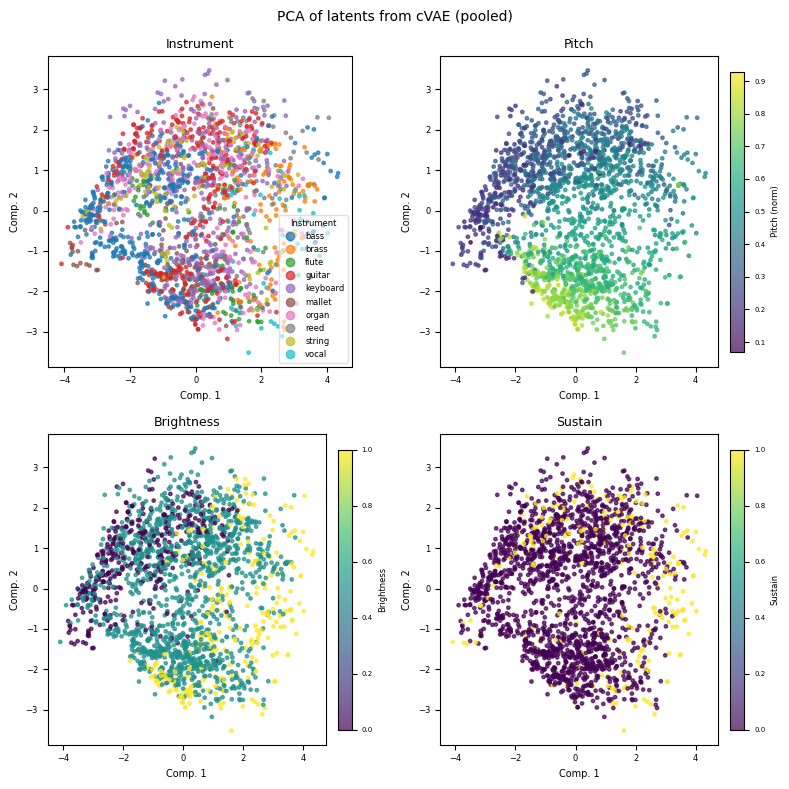

[t-SNE] reducido con PCA de 640 a 50 dimensiones antes de t-SNE


c:\Users\Articuno\Desktop\TFG-MUSICAL\env-musical-serious-business\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning:

Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.

  File "c:\Users\Articuno\Desktop\TFG-MUSICAL\env-musical-serious-business\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


[t-SNE] terminado (perplexity=30, KL divergence final=0.924)
Guardado en tsne_latents_grid.png


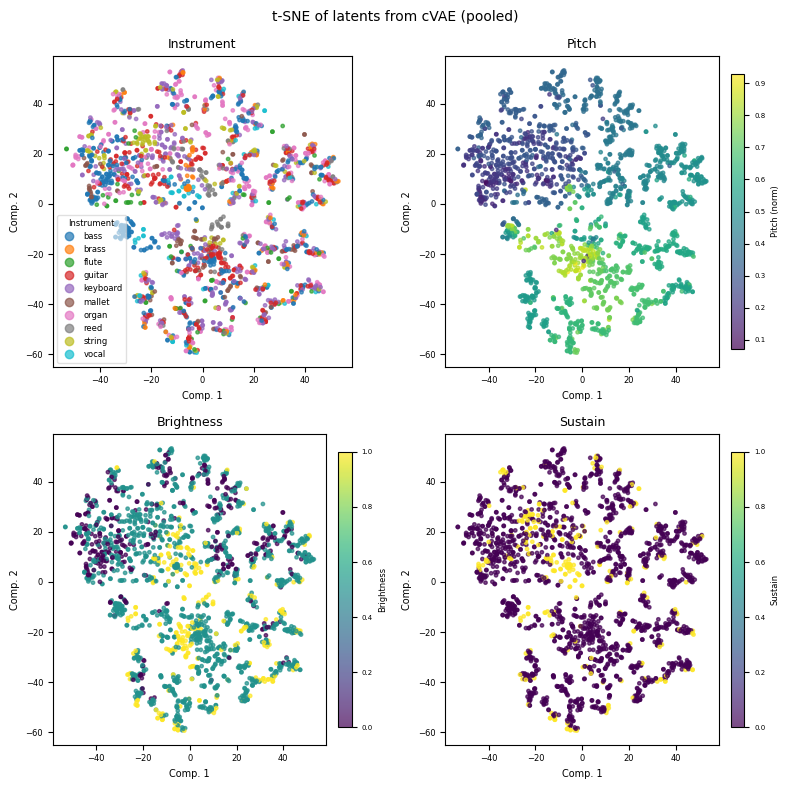

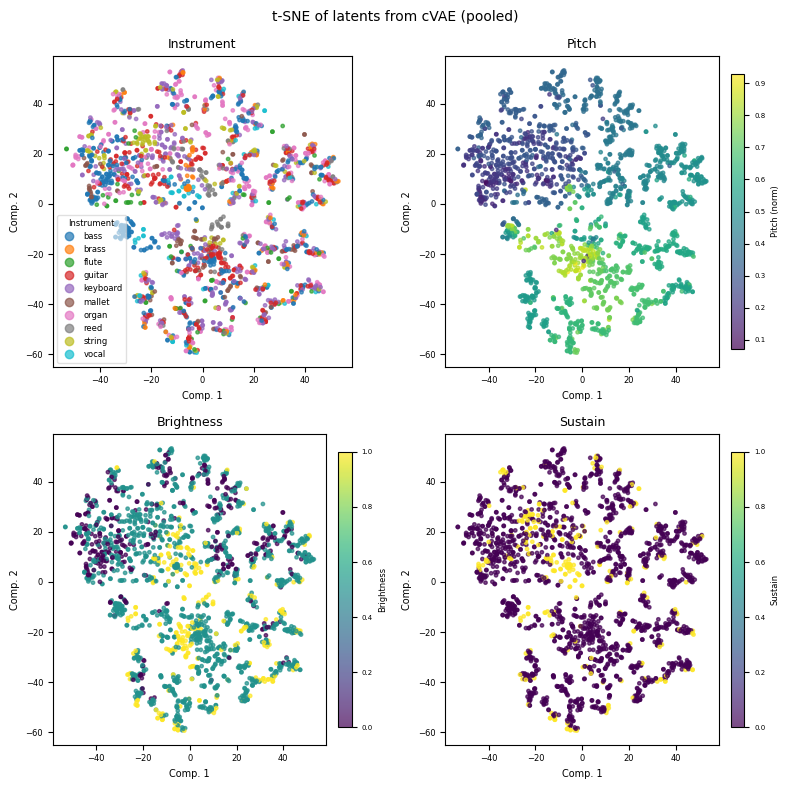

In [15]:
import os
os.environ.setdefault("LOKY_MAX_CPU_COUNT", str(os.cpu_count() or 4))  # evita el warning de joblib al no detectar núcleos físicos

import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

# Asume que 'model', 'device', 'conditions_to_device' y 'NOMBRES_INSTRUMENTOS'
# ya existen en tu notebook (igual que los usa reconstruir_desde_loader).


@torch.no_grad()
def extract_latents_cvae(loader, model, N=3000, determinista=True):
    """
    Pasa batches por el cVAE completo (forward, no solo encoder) y devuelve:
      - mus: latentes mu aplanados tal cual, uno por muestra
      - mus_pooled: si mu tiene dimensiones espaciales/temporales (p.ej.
                    [B, latent_dim, H, W] en un encoder convolucional sobre
                    el mel), promedia la última dimensión (tiempo) antes de
                    aplanar -- igual que se hacía en el VAE plano. Si mu ya
                    es 2D ([B, latent_dim]), mus_pooled == mus.
      - labels: nombre de instrumento por muestra (para colorear categórico)
      - cond_values: dict con arrays continuos (pitch, velocity, brightness,
                      sustain) por si quieres colorear por condición en vez
                      de por instrumento

    determinista=True usa z=mu (sin ruido de reparametrización), igual que en
    reconstruir_desde_loader -- recomendado para que el embedding sea
    repetible y refleje la media aprendida, no una muestra ruidosa de la
    posterior.

    Para en cuanto junta N muestras (no agota el loader entero).
    """
    mus, mus_pooled, labels = [], [], []
    pitches, velocities, brightnesses, sustains = [], [], [], []

    reparam_original = model.reparameterize
    if determinista:
        model.reparameterize = lambda mu, logvar: mu
    try:
        for mels, keys, metadatas, _, conditions in loader:
            mel = mels.to(device)
            cond = conditions_to_device(conditions, device)

            _, _, _, mu, _ = model(
                mel,
                cond['instrument_onehot'],
                cond['pitch_norm'],
                cond['velocity_norm'],
                cond['brightness'],
                cond['sustain'],
            )

            mus.append(mu.flatten(start_dim=1).cpu().numpy())

            if mu.dim() > 2:
                mu_pooled = mu.mean(dim=-1).flatten(start_dim=1)  # promedia en tiempo (última dim)
            else:
                mu_pooled = mu
            mus_pooled.append(mu_pooled.cpu().numpy())

            inst_idx = cond['instrument_onehot'].argmax(dim=1).cpu().numpy()
            labels.extend(NOMBRES_INSTRUMENTOS.get(int(idx), '?') for idx in inst_idx)

            pitches.extend(cond['pitch_norm'].cpu().numpy().ravel().tolist())
            velocities.extend(cond['velocity_norm'].cpu().numpy().ravel().tolist())
            brightnesses.extend(cond['brightness'].cpu().numpy().ravel().tolist())
            sustains.extend(cond['sustain'].cpu().numpy().ravel().tolist())

            if len(labels) >= N:
                break
    finally:
        model.reparameterize = reparam_original  # restaurar siempre, incluso si algo falla

    mus         = np.vstack(mus)[:N]
    mus_pooled  = np.vstack(mus_pooled)[:N]
    labels      = np.array(labels[:N])
    cond_values = {
        'pitch':      np.array(pitches[:N]),
        'velocity':   np.array(velocities[:N]),
        'brightness': np.array(brightnesses[:N]),
        'sustain':    np.array(sustains[:N]),
    }
    return mus, mus_pooled, labels, cond_values


# ---------------- Reducción a 2D ----------------
# Separo "calcular el embedding" de "dibujarlo" para no repetir el fit de
# PCA/t-SNE una vez por cada variable de color (antes se recalculaba entero
# por cada plot). Así el mismo embedding 2D se reutiliza en los 4 paneles
# de cada figura.

def pca_embed(features, random_state=42):
    pca = PCA(n_components=2, random_state=random_state)
    z2 = pca.fit_transform(features)
    var = pca.explained_variance_ratio_
    print(f"[PCA] varianza explicada PC1={var[0]:.3f} PC2={var[1]:.3f} (total={var.sum():.3f})")
    return z2


def tsne_embed(features, perplexity=30, learning_rate="auto", max_iter=1000,
               random_state=42, pca_components=50):
    """Si features tiene muchas dimensiones, reduce antes con PCA a
    pca_components (evita el MemoryError visto con inputs de alta
    dimensionalidad y acelera bastante el cálculo)."""
    n_samples, n_features = features.shape
    max_components = min(n_samples - 1, n_features)
    n_pca = min(pca_components, max_components)

    if n_pca < n_features:
        features = PCA(n_components=n_pca, random_state=random_state).fit_transform(features)
        print(f"[t-SNE] reducido con PCA de {n_features} a {n_pca} dimensiones antes de t-SNE")

    tsne = TSNE(
        n_components=2,
        perplexity=min(perplexity, n_samples - 1),
        learning_rate=learning_rate,
        max_iter=max_iter,
        init="pca",           # más estable y reproducible que init="random"
        random_state=random_state,
        n_jobs=1,              # evita que joblib/loky duplique buffers entre procesos
    )
    z2 = tsne.fit_transform(features)
    print(f"[t-SNE] terminado (perplexity={perplexity}, KL divergence final={tsne.kl_divergence_:.3f})")
    return z2


# ---------------- Dibujo en grid 2x2 ----------------

def _scatter_on_ax(ax, z2, color_values, title, categorical=True, legend_title="Instrument"):
    if categorical:
        unique_vals = np.unique(color_values)
        val2code = {v: i for i, v in enumerate(unique_vals)}
        codes = np.array([val2code[v] for v in color_values])
        scatter = ax.scatter(z2[:, 0], z2[:, 1], c=codes, cmap='tab10', s=6, alpha=0.7)
        handles, _ = scatter.legend_elements(num=len(unique_vals))
        ax.legend(handles, unique_vals, title=legend_title, loc='best',
                  fontsize=6, title_fontsize=6, framealpha=0.6)
    else:
        scatter = ax.scatter(z2[:, 0], z2[:, 1], c=color_values, cmap='viridis', s=6, alpha=0.7)
        cbar = plt.colorbar(scatter, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label(legend_title, fontsize=6)
        cbar.ax.tick_params(labelsize=5)

    ax.set_title(title, fontsize=9)
    ax.set_xlabel("Comp. 1", fontsize=7)
    ax.set_ylabel("Comp. 2", fontsize=7)
    ax.tick_params(labelsize=6)


def plot_grid(z2, panels, suptitle=None, figsize=(6, 6), save_path=None):
    """Dibuja 4 paneles (mismo embedding z2, coloreado distinto en cada uno)
    en una sola figura pequeña 2x2 -- pensada para pegar directamente en un PDF.

    panels: lista de 4 dicts con las claves:
        color_values, title, categorical (bool), legend_title
    save_path: si se indica, guarda la figura (png, dpi alto, márgenes ajustados)
    """
    assert len(panels) == 4, "plot_grid espera exactamente 4 paneles"

    fig, axes = plt.subplots(2, 2, figsize=figsize)
    for ax, p in zip(axes.flat, panels):
        _scatter_on_ax(ax, z2, p['color_values'], p['title'],
                        categorical=p.get('categorical', True),
                        legend_title=p.get('legend_title', 'Instrument'))

    if suptitle:
        fig.suptitle(suptitle, fontsize=10)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=200, bbox_inches='tight')
        print(f"Guardado en {save_path}")
    plt.show()
    return fig


# ---------------- Run ----------------
# Usa valid_loader o train_loader, los que ya tengas definidos en el notebook.
mus, mus_pooled, labels, cond_values = extract_latents_cvae(valid_loader, model, N=2000, determinista=True)

# 4 condiciones por figura (instrumento + pitch + brightness + sustain,
# sin velocity) -- mismo embedding reutilizado en los 4 paneles
panels = [
    dict(color_values=labels,                    title="Instrument",  categorical=True,  legend_title="Instrument"),
    dict(color_values=cond_values['pitch'],       title="Pitch",        categorical=False, legend_title="Pitch (norm)"),
    dict(color_values=cond_values['brightness'],  title="Brightness",   categorical=False, legend_title="Brightness"),
    dict(color_values=cond_values['sustain'],     title="Sustain",      categorical=False, legend_title="Sustain"),
]

z2_pca = pca_embed(mus_pooled)
plot_grid(z2_pca, panels, suptitle="PCA of latents from cVAE (pooled)",
          save_path="pca_latents_grid.png", figsize=(8,8))

z2_tsne = tsne_embed(mus_pooled)
plot_grid(z2_tsne, panels, suptitle="t-SNE of latents from cVAE (pooled)",
          save_path="tsne_latents_grid.png", figsize=(8,8))

### Pruebas de Generacion

In [ ]:
import inspect
import torch
import torch.nn.functional as F
import json



def _llamar_D(D, z, t_batch, cond):
    """
    Llama a D adaptandose a su firma real, para no asumir a ciegas que
    acepta condiciones:
      - Si D.forward(z, t) solo acepta 2 argumentos -> se ignora `cond`.
        El modelo de difusion genera SIN condicionar; el instrumento/
        pitch/velocity/brillo/sustain solo se aplican despues, al
        decodificar z con el decoder del cVAE.
      - Si D.forward(z, t, cond) acepta 3+ -> se le pasa `cond`.
    """
    n_params = len(inspect.signature(D.forward).parameters)
    if n_params >= 3:
        return D(z, t_batch, cond)
    return D(z, t_batch)


@torch.no_grad()
def generar_desde_difusion(D, D_scheduler, n=4,
                            instrumento_idx=None,
                            pitch_norm=None,
                            velocity_norm=None,
                            brightness=None,
                            sustain=None,
                            latent_shape=(128, 5, 8),
                            guidance_scale=1.0,
                            clip_val=4.0):
    lc, lh, lw = latent_shape

    def _resolver(*nombres):
        for nombre in nombres:
            if hasattr(D_scheduler, nombre):
                return getattr(D_scheduler, nombre)
        disponibles = [a for a in dir(D_scheduler) if not a.startswith('_')]
        raise AttributeError(
            f"D_scheduler no tiene ninguno de estos atributos: {nombres}. "
            f"Atributos disponibles: {disponibles}"
        )

    betas      = _resolver('beta', 'betas')
    alphas     = _resolver('alpha', 'alphas')
    alpha_bars = _resolver('alpha_bar', 'alpha_bars')
    num_train_timesteps = betas.shape[0]   # <- FIX: los 1000 pasos completos, no //10

    if instrumento_idx is None:
        instrumento_idx = torch.randint(0, N_INSTRUMENTOS, (n,))
    else:
        instrumento_idx = torch.as_tensor(instrumento_idx).view(-1)
        if instrumento_idx.shape[0] == 1:
            instrumento_idx = instrumento_idx.expand(n)
    instrument_onehot = F.one_hot(instrumento_idx, num_classes=N_INSTRUMENTOS).float().to(device)

    def _prep(valor):
        if valor is None:
            return torch.rand(n, 1, device=device)
        t = torch.as_tensor(valor, dtype=torch.float32).view(-1, 1)
        if t.shape[0] == 1:
            t = t.expand(n, 1)
        return t.to(device)

    cond = {
        'instrument_onehot': instrument_onehot,
        'pitch_norm':        _prep(pitch_norm),
        'velocity_norm':     _prep(velocity_norm),
        'brightness':        _prep(brightness),
        'sustain':           _prep(sustain),
    }

    # --- Proceso reverso de difusion CON clipping (única pasada, sin bucle duplicado) ---
    z = torch.randn(n, lc, lh, lw, device=device)

    for t in reversed(range(num_train_timesteps)):
        t_batch = torch.full((n,), t, device=device, dtype=torch.long)

        if guidance_scale != 1.0:
            e_cond   = _llamar_D(D, z, t_batch, cond)
            e_uncond = _llamar_D(D, z, t_batch, None)
            e_pred = e_uncond + guidance_scale * (e_cond - e_uncond)
        else:
            e_pred = _llamar_D(D, z, t_batch, cond)

        beta_t      = betas[t]
        alpha_t     = alphas[t]
        alpha_bar_t = alpha_bars[t]

        x0_pred = (z - torch.sqrt(1 - alpha_bar_t) * e_pred) / torch.sqrt(alpha_bar_t)
        x0_pred = torch.clamp(x0_pred, -clip_val, clip_val)

        if t > 0:
            alpha_bar_prev = alpha_bars[t - 1]
            coef_x0 = (torch.sqrt(alpha_bar_prev) * beta_t) / (1 - alpha_bar_t)
            coef_zt = (torch.sqrt(alpha_t) * (1 - alpha_bar_prev)) / (1 - alpha_bar_t)
            mean = coef_x0 * x0_pred + coef_zt * z
            sigma_t = torch.sqrt(beta_t * (1 - alpha_bar_prev) / (1 - alpha_bar_t))
            z = mean + sigma_t * torch.randn_like(z)
        else:
            z = x0_pred

        # if t % 100 == 0:
            # print(f"t={t}: std={z.std().item():.4f}, max={z.abs().max().item():.4f}")

    # --- Desnormalizar z a la escala original de mu (revierte normalize_latents) ---
    with open(os.path.join(PATHS['cvae_diffusion']['dataset_training'], 'stats.json')) as f:
        _stats = json.load(f)
    _mean, _std = _stats['mean'], _stats['std']

    z_dec = z * _std + _mean
    print(f"[generar_desde_difusion] z_dec: mean={z_dec.mean().item():.4f}, std={z_dec.std().item():.4f}, "
          f"max={z_dec.max().item():.4f}, min={z_dec.min().item():.4f}")

    H_lat, W_lat = model.latent_hw
    c_map = model._condition_map(
        cond['instrument_onehot'], cond['pitch_norm'], cond['velocity_norm'],
        cond['brightness'], cond['sustain'], hw=(H_lat, W_lat),
    )
    zc       = torch.cat([z_dec, c_map], dim=1)
    mel_hat  = model.decoder_mel(zc)
    ddsp_out = model.decoder_ddsp(zc)
    
    mel_hat, ddsp_out = model.sample(instrument_onehot=cond['instrument_onehot'], pitch_norm=cond['pitch_norm'], velocity_norm=cond['velocity_norm'], brightness=cond['brightness'], sustain=cond['sustain'], z=z_dec, n_samples=n)
    

    resultados = []
    for i in range(n):
        inst_idx = int(cond['instrument_onehot'][i].argmax().item())
        resultados.append({
            'audio_hat': _mel_a_audio(mel_hat[i]),
            'mel_hat':   mel_hat[i].cpu(),
            'z':         z[i].cpu(),
            'config': {
                'instrumento':        inst_idx,
                'instrumento_nombre': NOMBRES_INSTRUMENTOS.get(inst_idx, '?'),
                'pitch_norm':         round(float(cond['pitch_norm'][i].item()), 3),
                'velocity_norm':      round(float(cond['velocity_norm'][i].item()), 3),
                'brightness':         round(float(cond['brightness'][i].item()), 3),
                'sustain':            round(float(cond['sustain'][i].item()), 3),
            },
        })

    return resultados


def mostrar_generaciones_difusion(resultados):
    """Analogo a mostrar_reconstrucciones(), pero solo hay audio generado
    (no hay 'original' porque no viene de un dato real del dataset)."""
    for i, r in enumerate(resultados):
        c = r['config']
        # print(f"[{i}] {c['instrumento_nombre']} (fam {c['instrumento']}) | "
        #       f"pitch_norm {c['pitch_norm']} | vel_norm {c['velocity_norm']} | "
        #       f"brightness {c['brightness']} | sustain {c['sustain']}")
        display(Audio(r['audio_hat'], rate=SAMPLE_RATE))


def probar_generacion_difusion(D, D_scheduler, n=4,
                                instrumento_idx=None,
                                pitch_norm=None,
                                velocity_norm=None,
                                brightness=None,
                                sustain=None,
                                latent_shape=(128, 5, 8),
                                guidance_scale=1.0,
                                clip_val=4.0
                                ):
    """
    Atajo para generar y escuchar de una: usa D y D_scheduler (ya
    entrenados/cargados en tu sesion) para samplear via difusion latente
    y muestra el resultado, sin tener que llamar generar_desde_difusion()
    y mostrar_generaciones_difusion() por separado.

    Ejemplos:
        # 4 muestras totalmente aleatorias (instrumento/pitch/etc random)
        probar_generacion_difusion(D, D_scheduler, n=4)

        # una muestra con condiciones especificas
        probar_generacion_difusion(D, D_scheduler, n=1,
                                    instrumento_idx=2, pitch_norm=0.5,
                                    velocity_norm=0.8, brightness=0.6, sustain=0.3)
    """
    resultados = generar_desde_difusion(
        D, D_scheduler, n=n,
        instrumento_idx=instrumento_idx,
        pitch_norm=pitch_norm,
        velocity_norm=velocity_norm,
        brightness=brightness,
        sustain=sustain,
        latent_shape=latent_shape,
        guidance_scale=guidance_scale,
        clip_val=clip_val
    )
    mostrar_generaciones_difusion(resultados)
    return resultados

In [ ]:

from src.diffusion_setups.setup_latent import setup_latent_model
from src.paths import PATHS, cVAE_CVAE_LATENT_DIM


D, scheduler, trans = setup_latent_model(
    timesteps=1000,
    emb_dim=256,        # más capacidad en el embedding temporal (128 -> 256)
    norm_groups=24,      # se mantiene, sigue dividiendo exacto
    hidden_dims=24*6,      # 64 -> 96 (96/16=6 ✓); progresión: [96, 192, 384]
    latent_dim=cVAE_CVAE_LATENT_DIM,
    deep=4,              # si activas downsampling real, podrías subir a 4
    increase_dims=True
)

D = torch.load(PATHS['cvae_diffusion']['model'], map_location=device)
D_scheduler = torch.load(PATHS['cvae_diffusion']['scheduler'], map_location=device)

# print(type(D_scheduler))
# print(D_scheduler.keys() if isinstance(D_scheduler, dict) else vars(D_scheduler))

probar_generacion_difusion(D, D_scheduler, n=2, instrumento_idx=2, pitch_norm=0.5, velocity_norm=0.8, brightness=0.6, sustain=0, clip_val=4.56)
probar_generacion_difusion(D, D_scheduler, n=2, instrumento_idx=1, pitch_norm=0.4, velocity_norm=0.8, brightness=0.6, sustain=1, clip_val=7.0)

t=900: std=1.0140, max=3.9793
t=800: std=1.0250, max=4.2681
t=700: std=1.0665, max=4.3156
t=600: std=1.1631, max=4.5261
t=500: std=1.3497, max=4.9246
t=400: std=1.6172, max=5.3498
t=300: std=1.9547, max=5.4538
t=200: std=2.2626, max=5.5567
t=100: std=2.4559, max=5.4403
t=0: std=2.4595, max=4.5600
[generar_desde_difusion] z_dec: mean=0.0747, std=0.6730, max=1.2469, min=-1.2488


t=900: std=1.0083, max=3.9177
t=800: std=1.0364, max=4.4769
t=700: std=1.1239, max=4.1980
t=600: std=1.3228, max=5.2105
t=500: std=1.6904, max=5.8730
t=400: std=2.2068, max=6.4853
t=300: std=2.8236, max=7.2142
t=200: std=3.4226, max=7.9738
t=100: std=3.8338, max=7.8855
t=0: std=3.9110, max=7.0000
[generar_desde_difusion] z_dec: mean=0.0767, std=1.0703, max=1.9146, min=-1.9165


[{'audio_hat': array([-0.00017639, -0.00186963, -0.00216722, ...,  0.00550256,
          0.01329791,  0.01678473], dtype=float32),
  'mel_hat': tensor([[[ 1.6503e-04,  3.4666e-04,  1.5455e-04,  ..., -1.2876e-04,
            -2.2842e-04, -1.0814e-04],
           [ 2.2757e-03,  1.4280e-02,  2.1994e-02,  ...,  2.2440e-04,
             1.8222e-05,  5.3753e-05],
           [ 2.2036e+00,  1.4443e+00,  5.4764e-01,  ..., -1.3594e-04,
            -1.8792e-04, -5.3698e-05],
           ...,
           [ 3.2460e-04,  1.6971e-04,  5.4340e-05,  ...,  4.2323e-05,
            -1.1285e-05,  9.4299e-06],
           [ 5.5873e-05, -7.1556e-06, -2.9549e-05,  ...,  1.1029e-05,
            -1.1754e-05, -3.0596e-06],
           [ 1.4284e-04,  1.0819e-05,  3.6815e-05,  ..., -6.9426e-05,
             6.0128e-06,  2.0403e-05]]]),
  'z': tensor([[[ 2.0110, -4.4377,  3.3693,  ..., -1.4494, -2.2292,  0.7707],
           [-4.2897, -2.1320, -1.7533,  ...,  3.1476,  2.5082, -2.6368],
           [-4.8320, -4.2485, -2.7